<a href="https://colab.research.google.com/github/odivibe/ai-projects/blob/main/CNN_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practice CNN with Digits (train.csv and test.csv)

### Setup and Imports

I will import the necessary libraries for data manipulation, visualization, and building a Convolutional Neural Network.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

### Define Global Parameters

Set the number of classes (digits 0-9) and the number of training epochs.

In [ ]:
num_classes = 10
epochs = 20

### Load the Datasets

I will load the `train-cnn.csv` (Fashion MNIST training data) and `test-cnn.csv` (Fashion MNIST test data) files directly from the Colab environment. Then, I'll display the first few rows and the shape of each dataset to inspect their structure.

In [ ]:
train_df = pd.read_csv('/content/train-cnn.csv')
test_df = pd.read_csv('/content/test-cnn.csv')

print('Train Dataset Head:')
display(train_df.head())
print('\nTrain Dataset Shape:', train_df.shape)

print('\nTest Dataset Head:')
display(test_df.head())
print('\nTest Dataset Shape:', test_df.shape)

Train Dataset Head:


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Train Dataset Shape: (42000, 785)

Test Dataset Head:


,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Test Dataset Shape: (28000, 784)


### Data Preprocessing

I will prepare the datasets for the CNN model by performing the following steps:
1.  Separate features (pixel data) and labels from the training data.
2.  Normalize the pixel values to a range between 0 and 1.
3.  Reshape the pixel data into a 28x28x1 format (height, width, channels) suitable for CNNs.
4.  Split the training data into training and validation sets. The test dataset (`test_df`) is used for final evaluation, assuming it's structured similarly to the Kaggle MNIST test set where labels are not present, or if present, we want to split our main train data into train/val/test to fully simulate a scenario with unseen data and evaluation.

In [ ]:
# Separate features (X) and labels (y) from the training data
x_full_train = train_df.drop('label', axis=1).values.astype('float32')
y_full_train = train_df['label'].values.astype('int')

# Normalize pixel values to 0-1 range
x_full_train /= 255.0

# Split the full training data into training, validation, and a test set for evaluation
x_train_temp, x_test_eval, y_train_temp, y_test_eval = train_test_split(
    x_full_train, y_full_train, test_size=0.2, random_state=42
)
x_train, x_validate, y_train, y_validate = train_test_split(
    x_train_temp, y_train_temp, test_size=0.25, random_state=42 # 0.25 of 0.8 is 0.2, so 60% train, 20% val, 20% test
)

# Preprocess the external test_df as well (assuming it contains pixel data similar to train_df)
# If 'test.csv' contains an ID column or different structure, adjust this part.
# Assuming 'test.csv' only contains pixel data for prediction.
x_final_test = test_df.values.astype('float32') / 255.0

# Reshape images to 28x28x1 for CNN input
image_rows, image_cols = 28, 28
image_shape = (image_rows, image_cols, 1)

x_train = x_train.reshape(x_train.shape[0], image_rows, image_cols, 1)
x_validate = x_validate.reshape(x_validate.shape[0], image_rows, image_cols, 1)
x_test = x_test_eval.reshape(x_test_eval.shape[0], image_rows, image_cols, 1) # Renaming x_test_eval for clarity
x_final_test = x_final_test.reshape(x_final_test.shape[0], image_rows, image_cols, 1)

y_test = y_test_eval # Renaming y_test_eval for clarity

print('Shape of x_train:', x_train.shape)
print('Shape of y_train:', y_train.shape)
print('Shape of x_validate:', x_validate.shape)
print('Shape of y_validate:', y_validate.shape)
print('Shape of x_test (for evaluation from train_df):', x_test.shape)
print('Shape of y_test (for evaluation from train_df):', y_test.shape)
print('Shape of x_final_test (from test.csv for potential submission):', x_final_test.shape)

Shape of x_train: (25200, 28, 28, 1)
Shape of y_train: (25200,)
Shape of x_validate: (8400, 28, 28, 1)
Shape of y_validate: (8400,)
Shape of x_test (for evaluation from train_df): (8400, 28, 28, 1)
Shape of y_test (for evaluation from train_df): (8400,)
Shape of x_final_test (from test.csv for potential submission): (28000, 28, 28, 1)


### Visualize Sample Digits

Let's display some sample images from our prepared training dataset along with their labels to visually confirm the preprocessing steps.

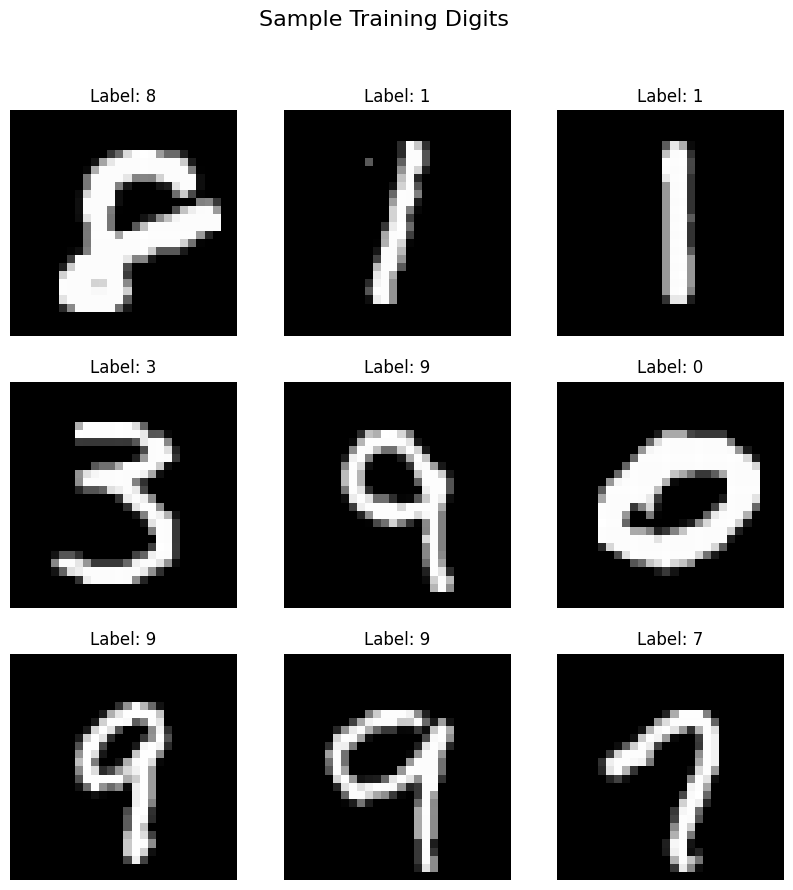

In [ ]:
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.suptitle('Sample Training Digits', fontsize=16)
plt.show()

### Distribution of Training Labels

Visualize the distribution of digit labels in the training dataset to check for any class imbalance.

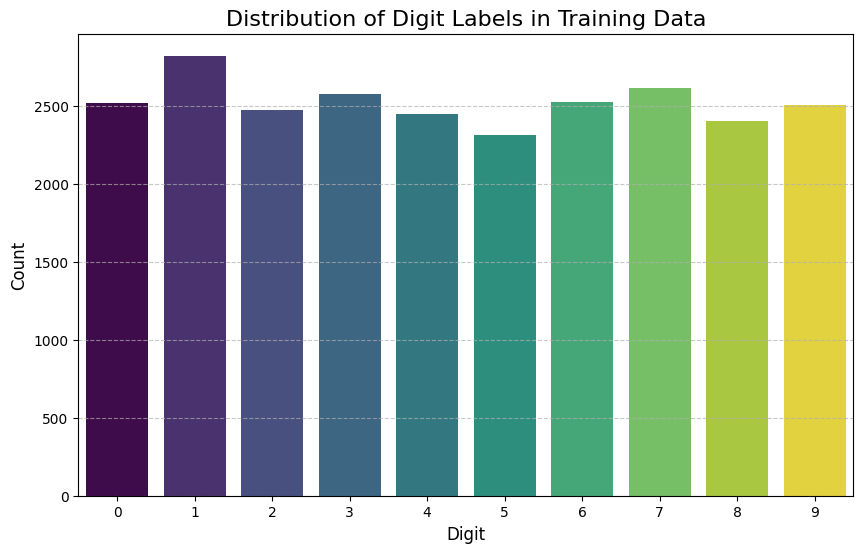

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x=y_train, hue=y_train, palette='viridis', legend=False)
plt.title('Distribution of Digit Labels in Training Data', fontsize=16)
plt.xlabel('Digit', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### CNN Model Building

Now, I will define the architecture of our Convolutional Neural Network (CNN) model using Keras. The model will consist of several convolutional and pooling layers, followed by flatten and dense layers for classification. Dropout layers will be included to help prevent overfitting.

In [ ]:
# Define the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=image_shape),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax') # `num_classes` for digits
])

# Compile the model using sparse_categorical_crossentropy for integer labels
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Display model summary
print(model.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

None


### Visualize CNN Model Architecture

Let's visualize the architecture of the defined CNN model to better understand its layers and connections.

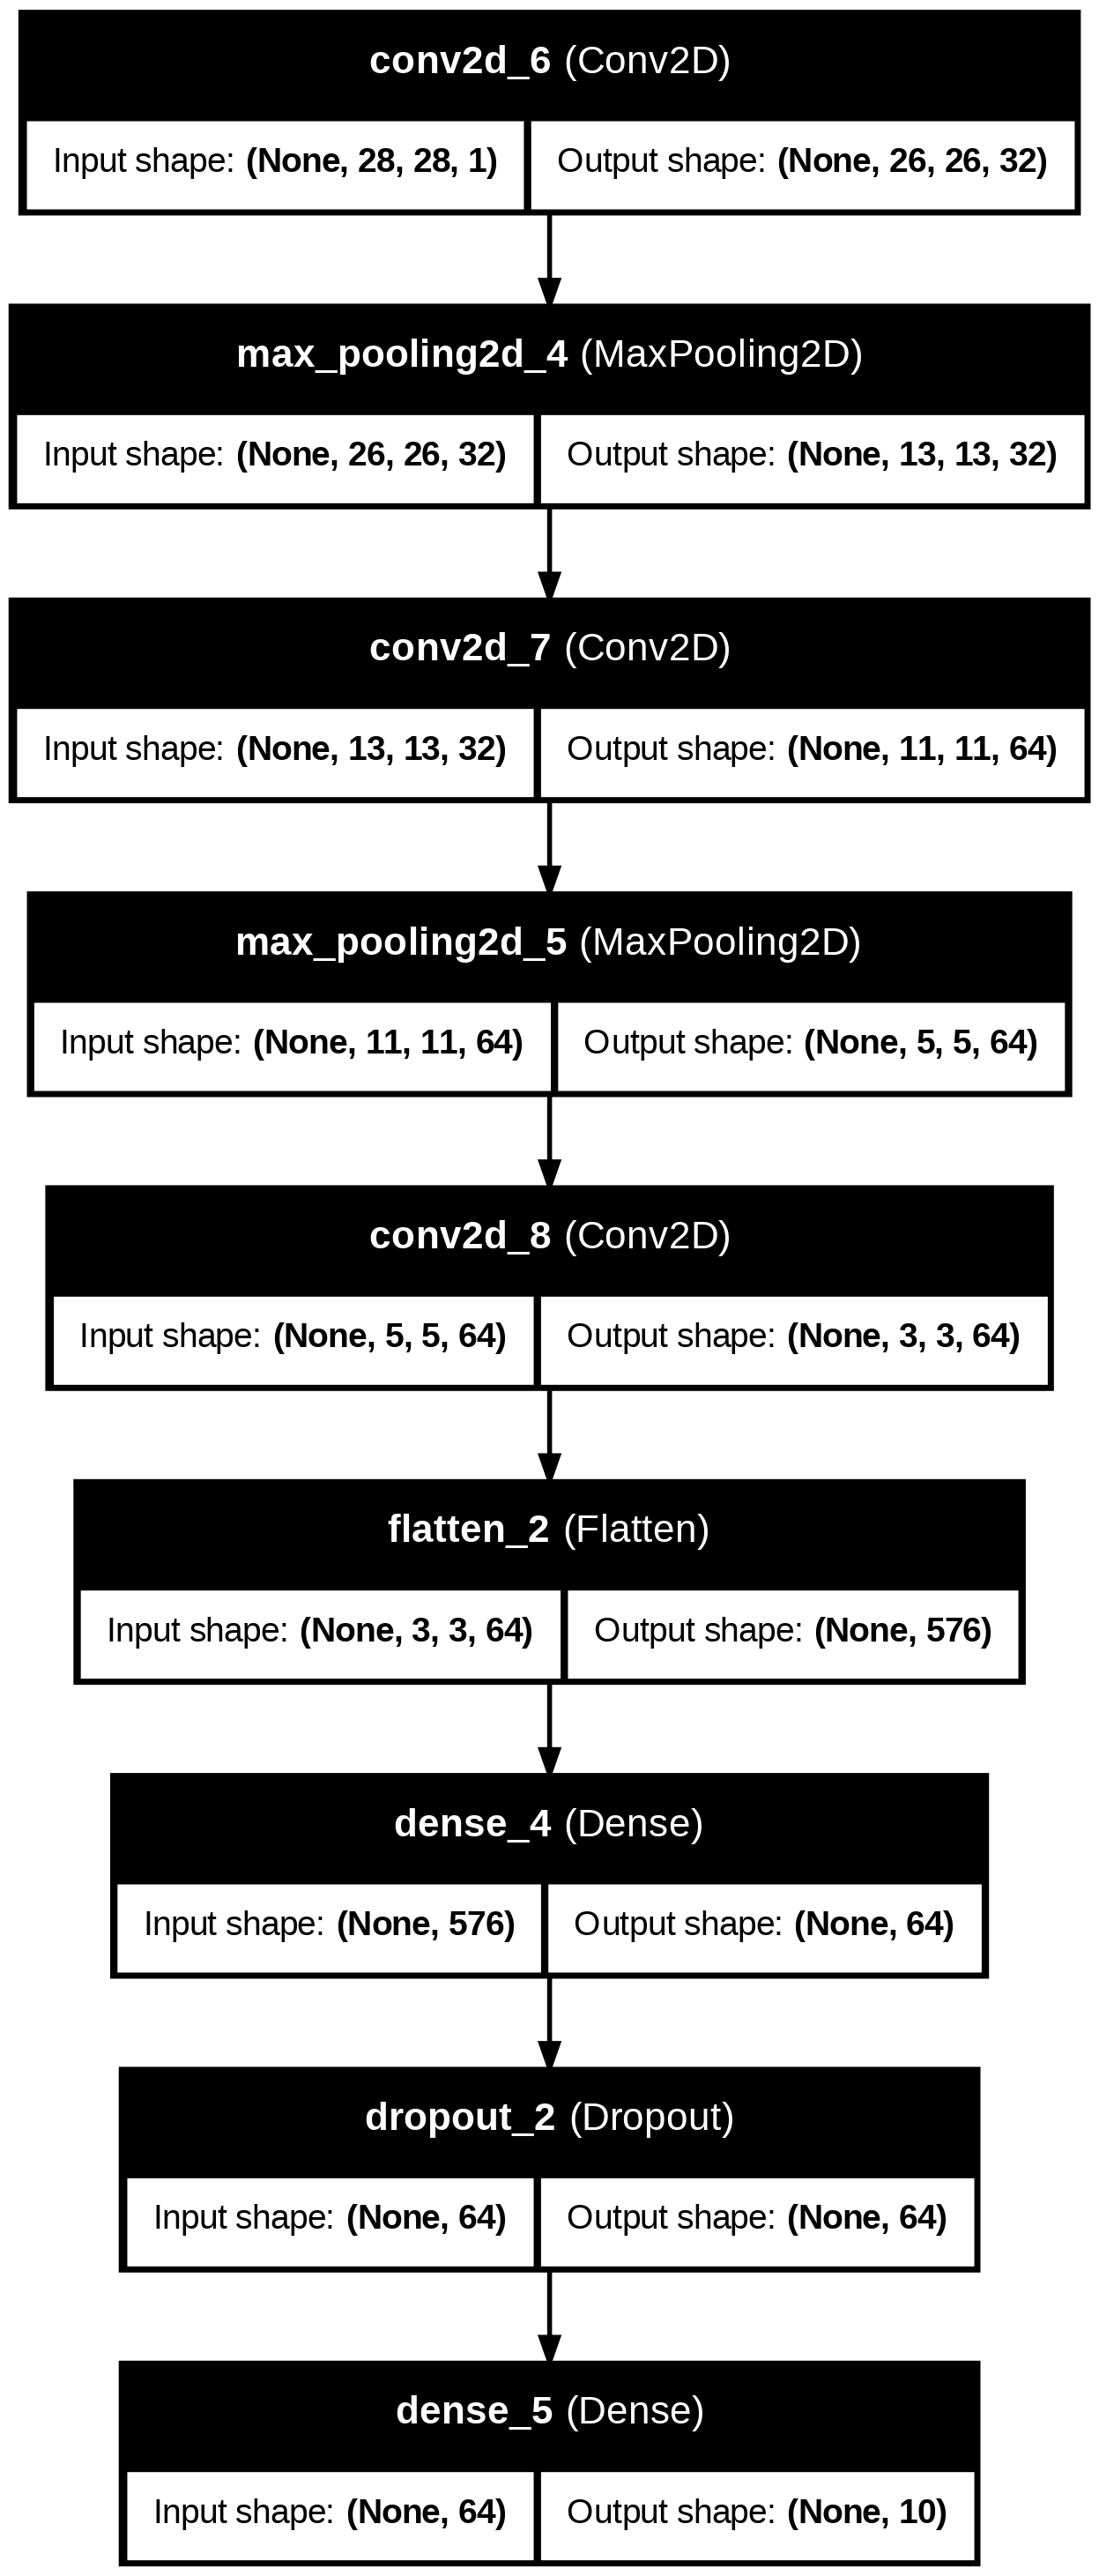

In [ ]:
# Plot the model architecture
plot_model(model, to_file='cnn_model_architecture.png', show_shapes=True, show_layer_names=True)

# Display the image (optional, as plot_model saves it to a file)
from IPython.display import Image
Image('cnn_model_architecture.png')

### CNN Model Training

I will now train the CNN model using the preprocessed training data (`x_train`, `y_train`). The training will be performed for `epochs` (20) with a `batch_size` of 128, and validated on `x_validate` and `y_validate`.

In [ ]:
batch_size = 128
history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(x_validate, y_validate))

Epoch 1/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 21s 97ms/step - accuracy: 0.7832 - loss: 0.6788 - val_accuracy: 0.9604 - val_loss: 0.1334
Epoch 2/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 21s 103ms/step - accuracy: 0.9394 - loss: 0.2055 - val_accuracy: 0.9707 - val_loss: 0.0934
Epoch 3/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 19s 95ms/step - accuracy: 0.9584 - loss: 0.1401 - val_accuracy: 0.9782 - val_loss: 0.0688
Epoch 4/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 20s 103ms/step - accuracy: 0.9681 - loss: 0.1106 - val_accuracy: 0.9820 - val_loss: 0.0594
Epoch 5/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 19s 96ms/step - accuracy: 0.9735 - loss: 0.0924 - val_accuracy: 0.9825 - val_loss: 0.0605
Epoch 6/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 22s 102ms/step - accuracy: 0.9771 - loss: 0.0770 - val_accuracy: 0.9845 - val_loss: 0.0526
Epoch 7/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 19s 95ms/step - accuracy: 0.9796 - loss: 0.0707 - val_accuracy: 0.9824 - val_loss: 0.0582
Epoch 8/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 20s 103ms/step - accuracy: 0.9817 - loss: 0.062

### CNN Model Evaluation

Now that the model is trained, I'll evaluate its performance on the held-out test dataset (`x_test`, `y_test`) to assess how well it generalizes to unseen data from the original `train.csv` split.

In [ ]:
score = model.evaluate(x_test, y_test, verbose=0)
print('Test Loss : {:.4f}'.format(score[0]))
print('Test Accuracy : {:.4f}'.format(score[1]))

Test Loss : 0.0461
Test Accuracy : 0.9892


### Visualize Training History

Let's plot the training and validation accuracy and loss over the epochs to understand the model's learning process and identify potential overfitting or underfitting.

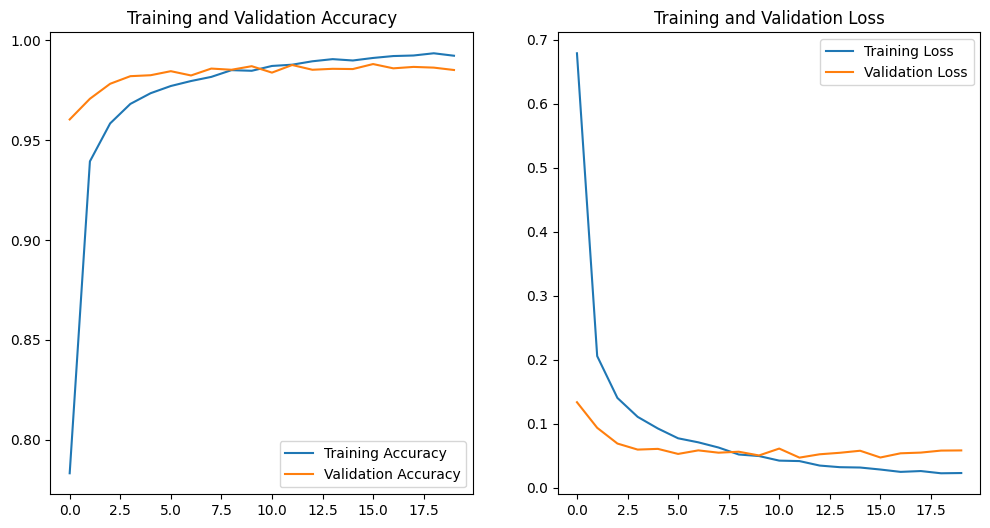

In [ ]:
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(epochs)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, accuracy, label='Training Accuracy')
plt.plot(epochs_range, val_accuracy, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

### Classification Report and Sample Predictions

Finally, let's generate a detailed classification report to see precision, recall, and f1-score for each Fashion MNIST class. We'll also visualize some sample test images with their predicted and true labels.

### Misclassified Images

Let's visualize some of the images that the CNN model misclassified to understand its errors.

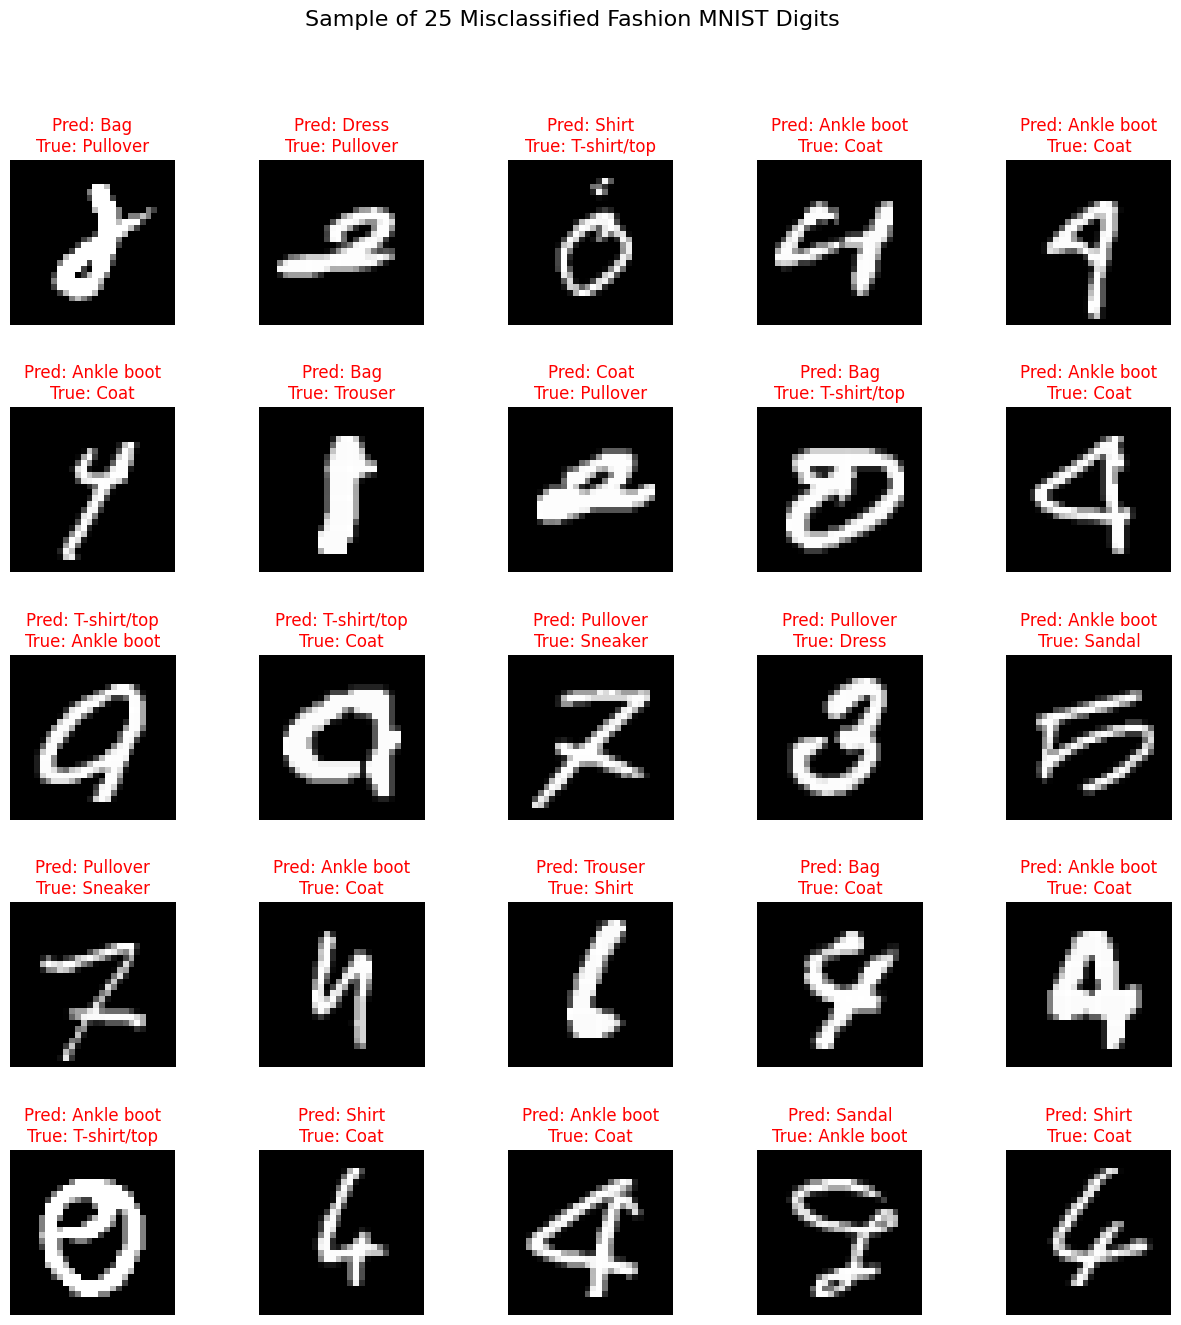

In [ ]:
# Define class names for Fashion MNIST for better readability
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Find indices of misclassified images
misclassified_indices = np.where(predicted_classes != y_test)[0]

# Take a sample of misclassified images to display (e.g., first 25 if available)
num_to_display = min(len(misclassified_indices), 25) # Display up to 25 misclassified images
sample_misclassified_indices = np.random.choice(misclassified_indices, num_to_display, replace=False)

L = int(np.ceil(np.sqrt(num_to_display)))
W = int(np.ceil(num_to_display / L))

fig, axes = plt.subplots(L, W, figsize=(15, 15))
axes = axes.ravel()

for i, idx in enumerate(sample_misclassified_indices):
    axes[i].imshow(x_test[idx].reshape(28, 28), cmap='gray')
    axes[i].set_title(f"Pred: {class_names[predicted_classes[idx]]}\nTrue: {class_names[int(y_test[idx])]}",
                      color='red') # Misclassified images in red
    axes[i].axis('off')

# Hide any unused subplots
for i in range(num_to_display, L * W):
    fig.delaxes(axes[i])

plt.subplots_adjust(wspace=0.5, hspace=0.5)
plt.suptitle(f'Sample of {num_to_display} Misclassified Fashion MNIST Digits', fontsize=16)
plt.show()

In [ ]:
# Get the predictions for the test data
predicted_classes = np.argmax(model.predict(x_test), axis=-1)

# Define class names for Fashion MNIST for better readability
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(classification_report(y_test, predicted_classes, target_names=class_names))

263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step
              precision    recall  f1-score   support

 T-shirt/top       1.00      0.99      0.99       816
     Trouser       1.00      0.99      0.99       909
    Pullover       0.99      0.99      0.99       846
       Dress       0.99      0.99      0.99       937
        Coat       1.00      0.97      0.98       839
      Sandal       0.99      0.99      0.99       702
       Shirt       0.98      1.00      0.99       785
     Sneaker       0.99      0.99      0.99       893
         Bag       0.99      0.99      0.99       835
  Ankle boot       0.97      0.99      0.98       838

    accuracy                           0.99      8400
   macro avg       0.99      0.99      0.99      8400
weighted avg       0.99      0.99      0.99      8400



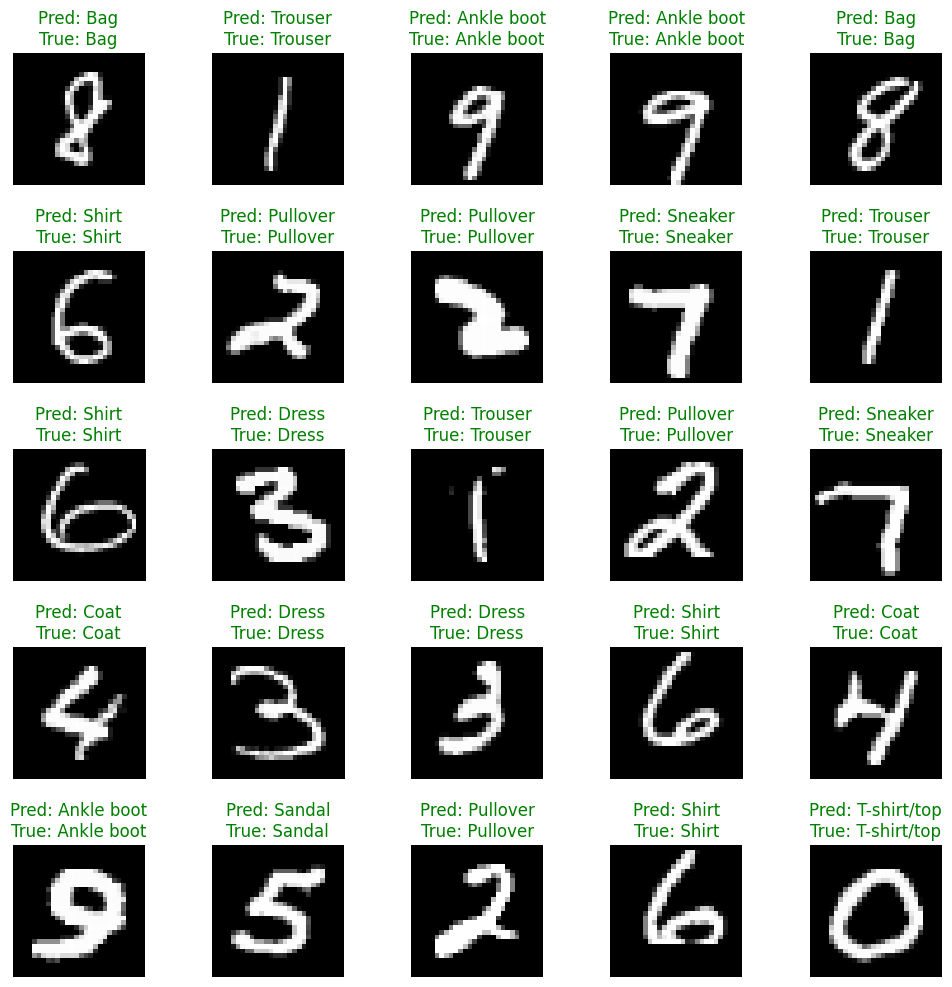

In [ ]:
# Define class names for Fashion MNIST for better readability
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

L = 5
W = 5
fig, axes = plt.subplots(L, W, figsize = (12,12))
axes = axes.ravel()

for i in np.arange(0, L * W):
    axes[i].imshow(x_test[i].reshape(28,28), cmap='gray')
    axes[i].set_title(f"Pred: {class_names[predicted_classes[i]]}\nTrue: {class_names[int(y_test[i])]}",
                      color='green' if predicted_classes[i] == int(y_test[i]) else 'red')
    axes[i].axis('off')

plt.subplots_adjust(wspace=0.5, hspace=0.5)
plt.show()

In [ ]:
!gdown 1lF36I1qDCgHFC9krLTGjvox4_xLWun2o
!gdown 1xe5wgvUttn6fs_FEtRhKLo8lOyMo3cjn

Downloading...
From: https://drive.google.com/uc?id=1lF36I1qDCgHFC9krLTGjvox4_xLWun2o
To: /content/test-cnn.csv
100% 51.1M/51.1M [00:01<00:00, 45.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1xe5wgvUttn6fs_FEtRhKLo8lOyMo3cjn
To: /content/train-cnn.csv
100% 76.8M/76.8M [00:01<00:00, 50.5MB/s]


In [ ]:
from subprocess import check_output
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import TensorBoard

In [ ]:
from subprocess import check_output
import warnings
warnings.filterwarnings('ignore')

import keras
from keras.optimizers import Adam
from keras.callbacks import TensorBoard

In [ ]:
num_classes = 10
epochs = 20

### MNIST Dataset

MNIST (Modified National Institute of Standards and Technology) is a large database of handwritten digits that is commonly used for training various image processing systems. The dataset consists of 60,000 training images and 10,000 testing images. Each image is a grayscale image of 28x28 pixels.

### Load the Datasets

I'll load the `train.csv` and `test.csv` files into pandas DataFrames. Then, I'll display the first 5 rows and the shape of each dataset to understand their structure.

In [ ]:
train_df = pd.read_csv('../input/fashionmnist/fashion-mnist_train.csv',sep=',')
test_df = pd.read_csv('../input/fashionmnist/fashion-mnist_test.csv', sep = ',')

print('Train Dataset Head:')
display(train_df.head())
print('\nTrain Dataset Shape:', train_df.shape)

print('\nTest Dataset Head:')
display(test_df.head())
print('\nTest Dataset Shape:', test_df.shape)

Train Dataset Head:


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Train Dataset Shape: (42000, 785)

Test Dataset Head:


,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Test Dataset Shape: (28000, 784)


### Data Preprocessing

I'll prepare the datasets for the CNN model by performing the following steps:
1.  Separate features (X) and labels (y) from the training data.
2.  Reshape the pixel data into a 28x28x1 format (height, width, channels) suitable for CNNs.
3.  Normalize the pixel values to a range between 0 and 1.
4.  One-hot encode the labels.

In [ ]:
# Convert DataFrames to numpy arrays for easier processing
train_data = np.array(train_df, dtype='float32')

# Separate features and labels from the main training data
# train_data[:, 0] is the label, train_data[:, 1:] are the pixel values
x_full_train = train_data[:, 1:] / 255.0  # Normalize features
y_full_train = train_data[:, 0]           # Labels

# Split the full training data into training, validation, and a test set for evaluation
# This creates a test set with labels for model evaluation, as the fashion-mnist_test.csv is unlabeled.
x_train_temp, x_test_eval, y_train_temp, y_test_eval = train_test_split(
    x_full_train, y_full_train, test_size=0.2, random_state=12345
)
x_train, x_validate, y_train, y_validate = train_test_split(
    x_train_temp, y_train_temp, test_size=0.25, random_state=12345 # 0.25 of 0.8 is 0.2, so 60% train, 20% val, 20% test
)

# Reshape images to 28x28x1
image_rows = 28
image_cols = 28
image_shape = (image_rows, image_cols, 1)

x_train = x_train.reshape(x_train.shape[0], image_rows, image_cols, 1)
x_validate = x_validate.reshape(x_validate.shape[0], image_rows, image_cols, 1)
x_test = x_test_eval.reshape(x_test_eval.shape[0], image_rows, image_cols, 1) # Renaming x_test_eval to x_test for consistency with user's script

# `y_train`, `y_validate`, `y_test` are left as integer labels as `sparse_categorical_crossentropy` will be used.
y_test = y_test_eval # Renaming y_test_eval to y_test for consistency with user's script

print('Shape of x_train:', x_train.shape)
print('Shape of y_train:', y_train.shape)
print('Shape of x_validate:', x_validate.shape)
print('Shape of y_validate:', y_validate.shape)
print('Shape of x_test (for evaluation):', x_test.shape)
print('Shape of y_test (for evaluation):', y_test.shape)

Shape of x_train: (25200, 28, 28, 1)
Shape of y_train: (25200,)
Shape of x_validate: (8400, 28, 28, 1)
Shape of y_validate: (8400,)
Shape of x_test (for evaluation): (8400, 28, 28, 1)
Shape of y_test (for evaluation): (8400,)


### Visualize Sample Digits

Let's display some sample images from the training dataset along with their labels to verify the preprocessing steps.

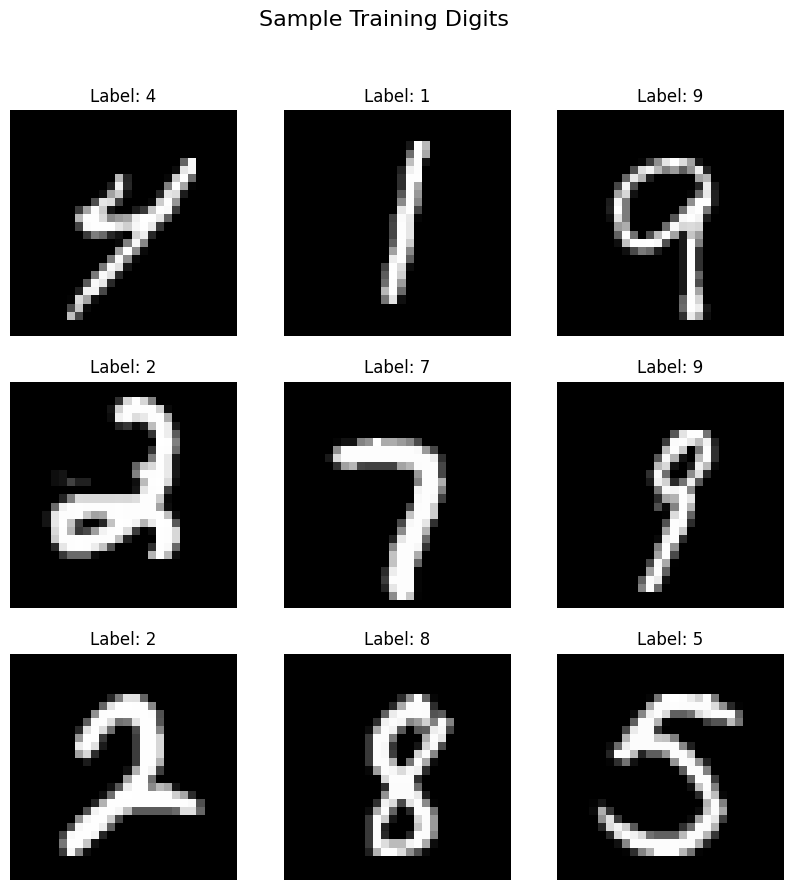

In [ ]:
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y_train[i]:.0f}") # y_train is already integer labels
    plt.axis('off')
plt.suptitle('Sample Training Digits', fontsize=16)
plt.show()

### Visualize Sample Fashion MNIST Images

Let's display some sample images from the preprocessed training dataset along with their Fashion MNIST labels to visually confirm the data.

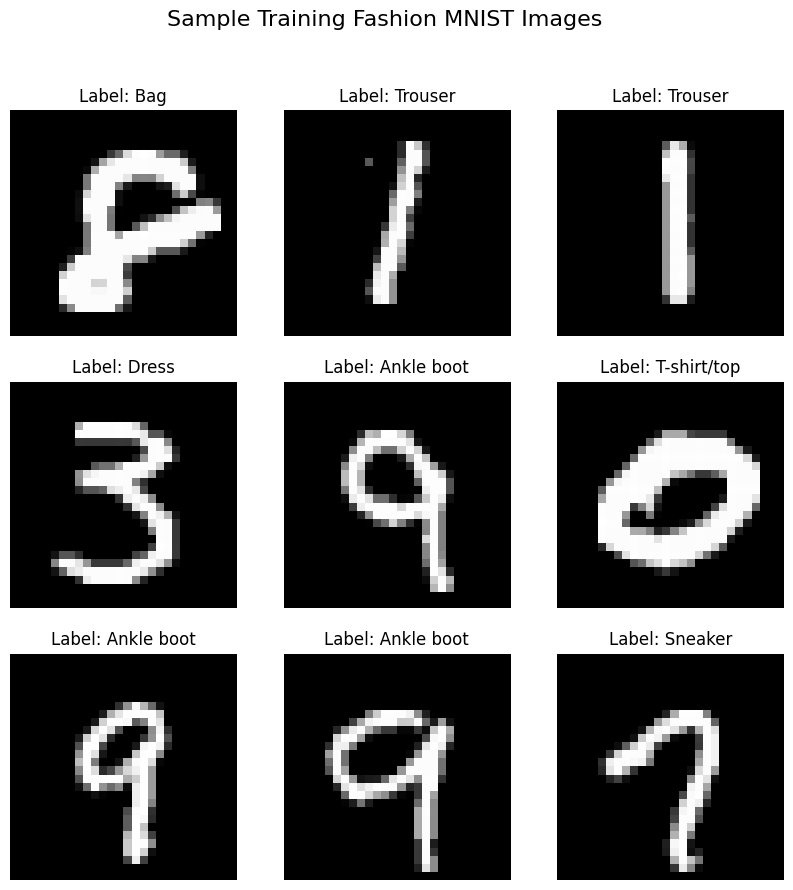

In [ ]:
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {class_names[int(y_train[i])]}") # Use class_names for Fashion MNIST
    plt.axis('off')
plt.suptitle('Sample Training Fashion MNIST Images', fontsize=16)
plt.show()

### Distribution of Training Labels

Let's visualize the distribution of the digit labels in the training dataset to check for any class imbalance.

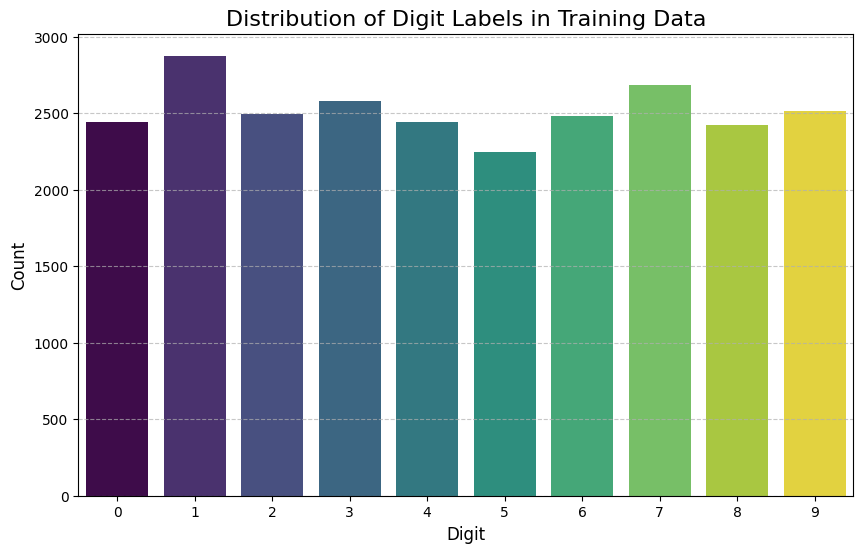

In [ ]:
import seaborn as sns
label_counts = y_train.astype(int) # y_train is already integer labels
plt.figure(figsize=(10, 6))
sns.countplot(x=label_counts, hue=label_counts, palette='viridis', legend=False)
plt.title('Distribution of Digit Labels in Training Data', fontsize=16)
plt.xlabel('Digit', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

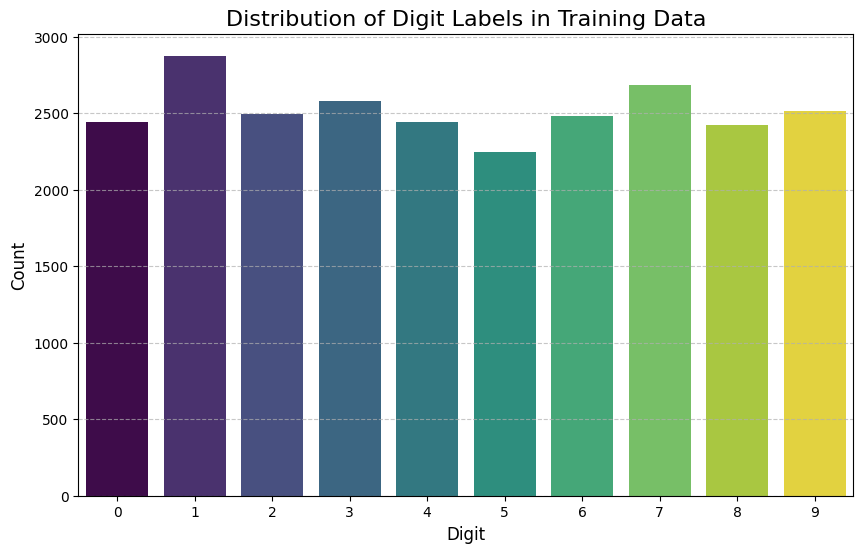

In [ ]:
label_counts = y_train.astype(int) # y_train is already integer labels
plt.figure(figsize=(10, 6))
sns.countplot(x=label_counts, hue=label_counts, palette='viridis', legend=False)
plt.title('Distribution of Digit Labels in Training Data', fontsize=16)
plt.xlabel('Digit', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### CNN Model Building

I will now define the architecture of our Convolutional Neural Network (CNN) model using Keras. The model will consist of several convolutional and pooling layers, followed by flatten and dense layers for classification. Dropout layers will be included to help prevent overfitting.

In [ ]:
# Define the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax') # 10 classes for digits
])

# Compile the model - changed to sparse_categorical_crossentropy for integer labels
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Display model summary
print(model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

None


### Visualize CNN Model Architecture

Let's visualize the architecture of the defined CNN model to better understand its layers and connections.

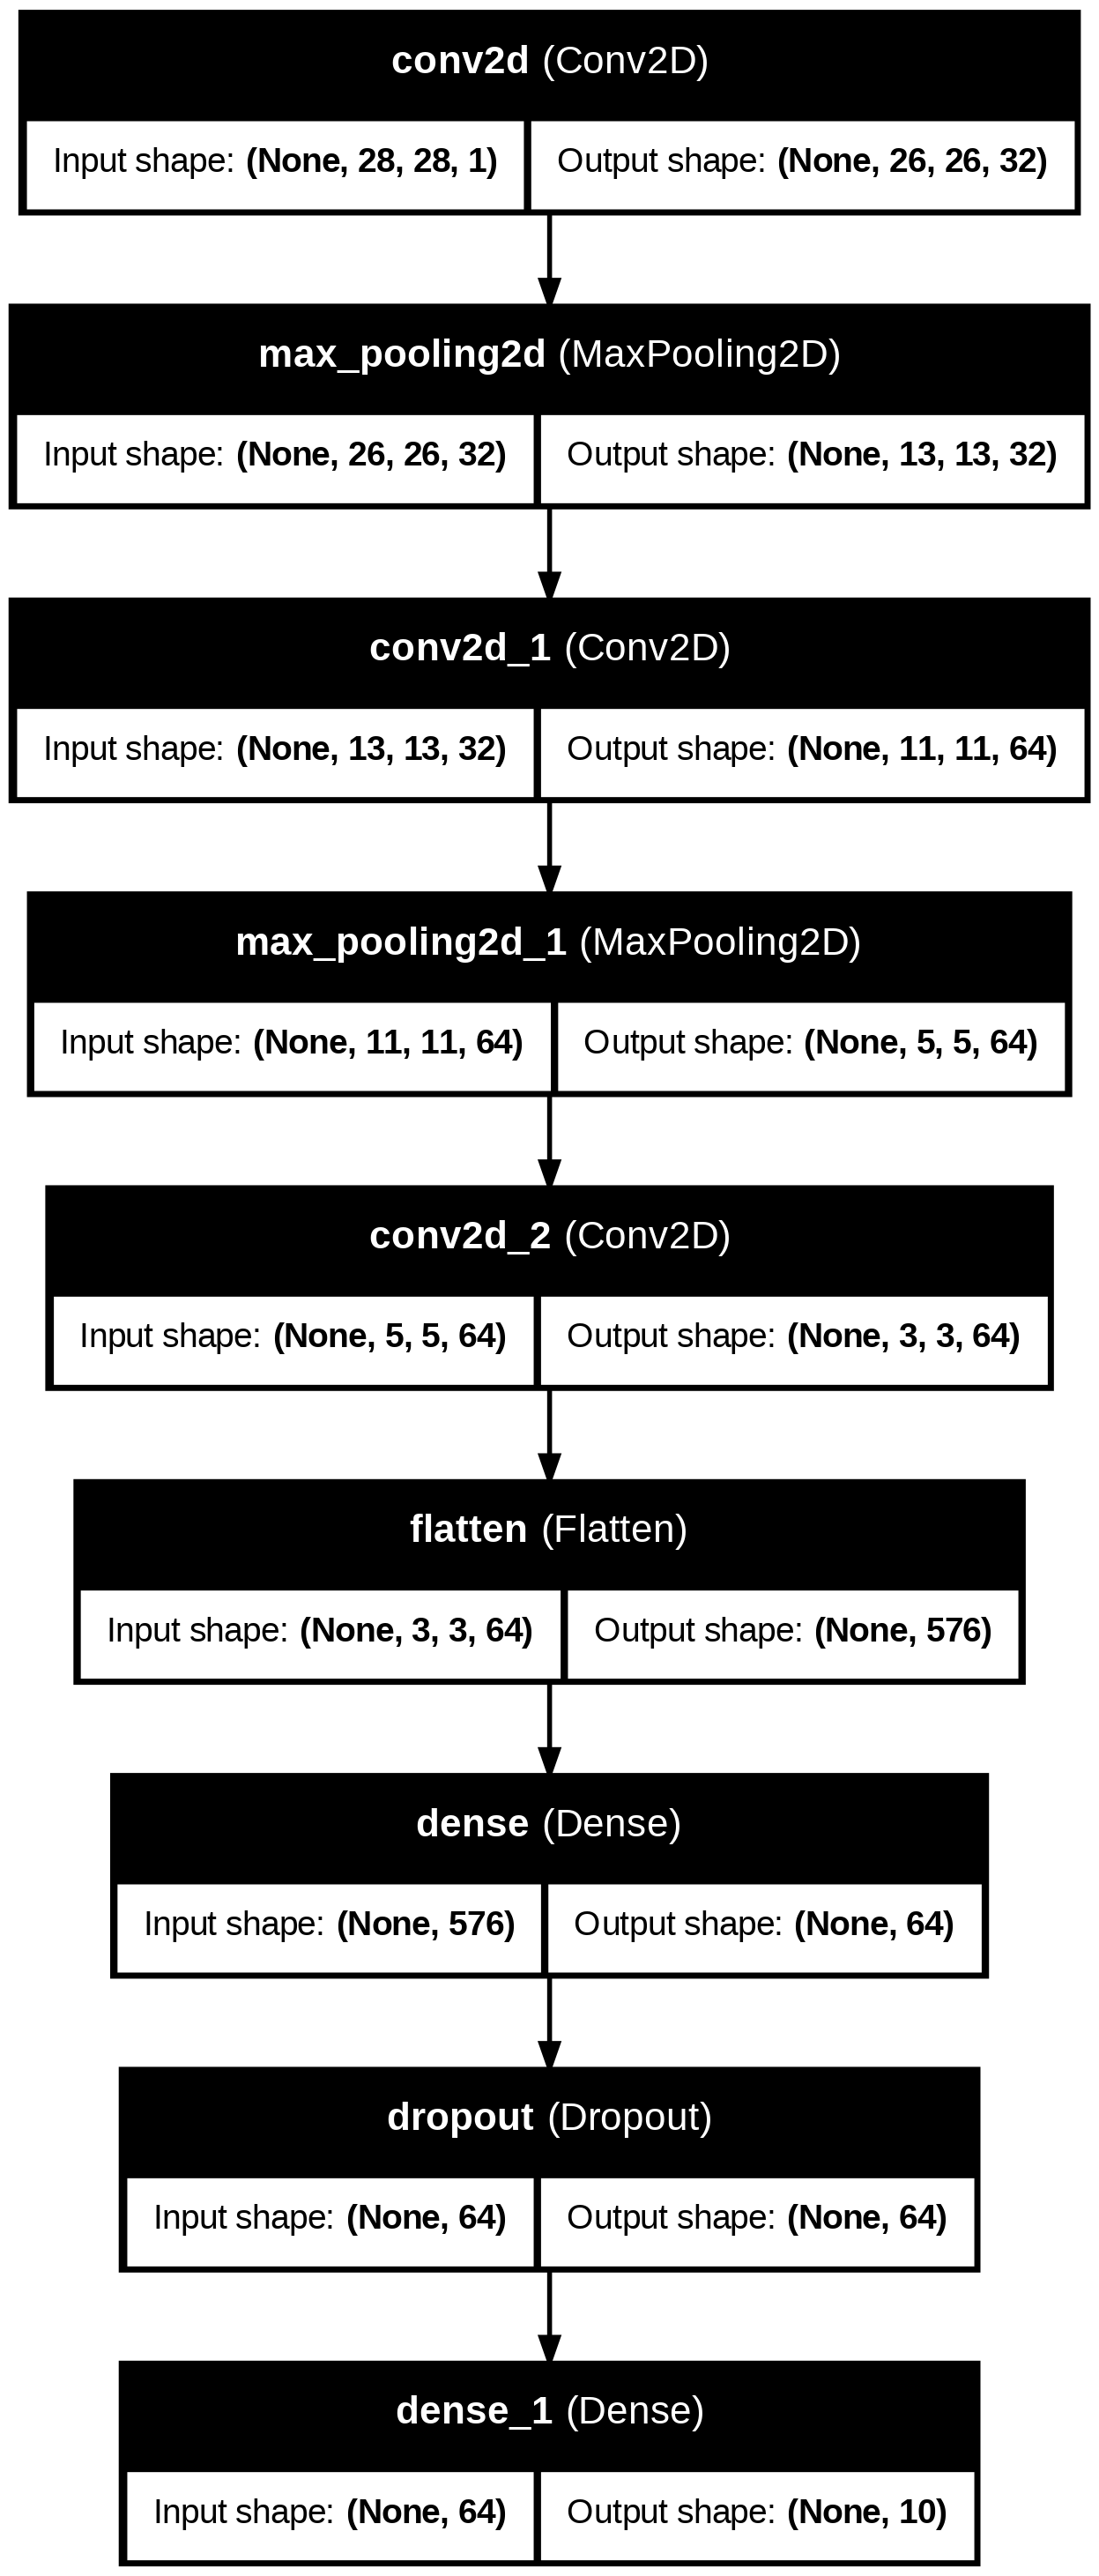

In [ ]:
from tensorflow.keras.utils import plot_model

# Plot the model architecture
plot_model(model, to_file='cnn_model_architecture.png', show_shapes=True, show_layer_names=True)

# Display the image (optional, as plot_model saves it to a file)
from IPython.display import Image
Image('cnn_model_architecture.png')

### CNN Model Training

I will now train the CNN model using the preprocessed training data (`X_train`, `y_train`). The training will be performed for `epochs` (20) with a `batch_size` of 128.

In [ ]:
batch_size = 128
history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)

Epoch 1/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 18s 92ms/step - accuracy: 0.7843 - loss: 0.6877 - val_accuracy: 0.9484 - val_loss: 0.1558
Epoch 2/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 18s 100ms/step - accuracy: 0.9416 - loss: 0.2033 - val_accuracy: 0.9683 - val_loss: 0.1049
Epoch 3/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 19s 92ms/step - accuracy: 0.9573 - loss: 0.1441 - val_accuracy: 0.9774 - val_loss: 0.0707
Epoch 4/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 21s 93ms/step - accuracy: 0.9674 - loss: 0.1107 - val_accuracy: 0.9813 - val_loss: 0.0610
Epoch 5/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 16s 91ms/step - accuracy: 0.9740 - loss: 0.0893 - val_accuracy: 0.9813 - val_loss: 0.0507
Epoch 6/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 16s 90ms/step - accuracy: 0.9769 - loss: 0.0792 - val_accuracy: 0.9849 - val_loss: 0.0485
Epoch 7/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 17s 97ms/step - accuracy: 0.9791 - loss: 0.0696 - val_accuracy: 0.9857 - val_loss: 0.0508
Epoch 8/20
178/178 ━━━━━━━━━━━━━━━━━━━━ 19s 90ms/step - accuracy: 0.9826 - loss: 0.0601 -

### CNN Model Evaluation

Now that the model is trained, I'll evaluate its performance on the `x_test` and `y_test` datasets to assess how well it generalizes to unseen data.

In [ ]:
score = model.evaluate(x_test, y_test, verbose=0)
print('Test Loss : {:.4f}'.format(score[0]))
print('Test Accuracy : {:.4f}'.format(score[1]))

Test Loss : 0.0482
Test Accuracy : 0.9894


### Visualize Training History

Let's plot the training and validation accuracy and loss over the epochs to understand the model's learning process.

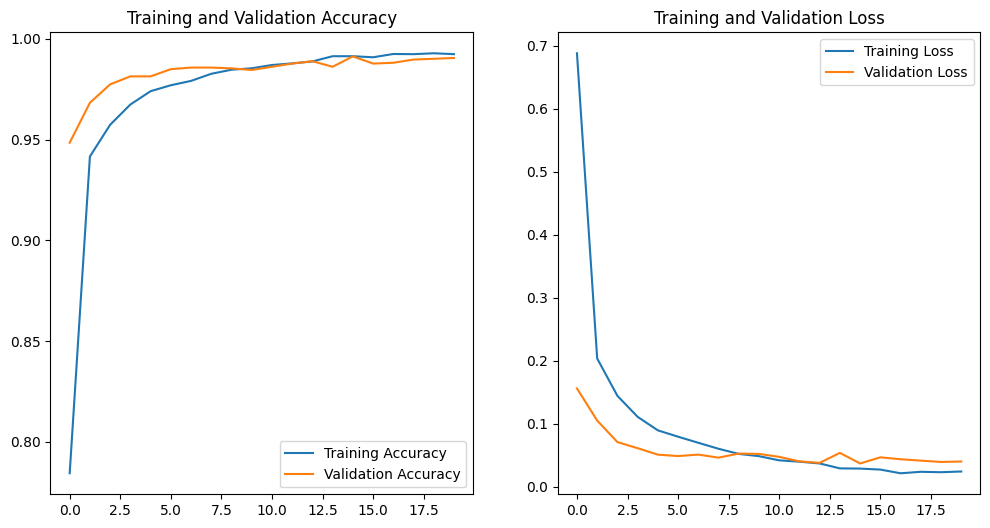

In [ ]:
import matplotlib.pyplot as plt

accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(epochs)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, accuracy, label='Training Accuracy')
plt.plot(epochs_range, val_accuracy, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

### Classification Report and Sample Predictions

Finally, let's generate a detailed classification report to see precision, recall, and f1-score for each class, and visualize some sample test images with their predicted and true labels.

In [ ]:
from sklearn.metrics import classification_report

# Get the predictions for the test data
predicted_classes = np.argmax(model.predict(x_test), axis=-1)

# Define class names for better readability in the report and plots
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(classification_report(y_test, predicted_classes, target_names=class_names))

263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
              precision    recall  f1-score   support

 T-shirt/top       0.99      1.00      1.00       862
     Trouser       0.99      0.99      0.99       921
    Pullover       0.98      1.00      0.99       813
       Dress       0.99      0.99      0.99       904
        Coat       0.98      0.99      0.99       804
      Sandal       0.99      0.98      0.99       773
       Shirt       0.99      0.99      0.99       814
     Sneaker       0.99      0.98      0.99       844
         Bag       0.99      0.98      0.99       828
  Ankle boot       0.99      0.98      0.98       837

    accuracy                           0.99      8400
   macro avg       0.99      0.99      0.99      8400
weighted avg       0.99      0.99      0.99      8400



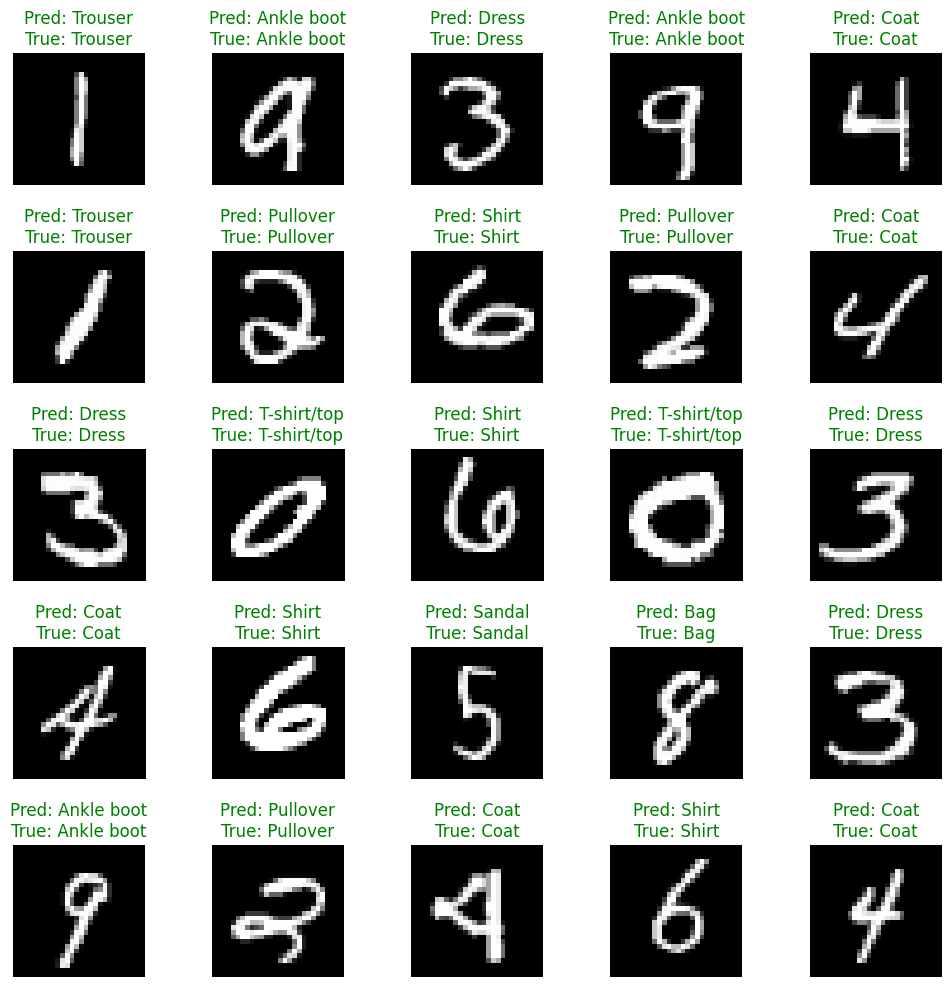

In [ ]:
L = 5
W = 5
fig, axes = plt.subplots(L, W, figsize = (12,12))
axes = axes.ravel()

for i in np.arange(0, L * W):
    axes[i].imshow(x_test[i].reshape(28,28), cmap='gray')
    axes[i].set_title(f"Pred: {class_names[predicted_classes[i]]}\nTrue: {class_names[int(y_test[i])]}",
                      color='green' if predicted_classes[i] == int(y_test[i]) else 'red')
    axes[i].axis('off')

plt.subplots_adjust(wspace=0.5, hspace=0.5)

### CNN Model Evaluation

Now that the model is trained, I'll evaluate its performance on the `x_test` and `y_test` datasets to assess how well it generalizes to unseen data.

In [ ]:
score = model.evaluate(x_test, y_test, verbose=0)
print('Test Loss : {:.4f}'.format(score[0]))
print('Test Accuracy : {:.4f}'.format(score[1]))

Test Loss : 0.0482
Test Accuracy : 0.9894


### Visualize Training History

Let's plot the training and validation accuracy and loss over the epochs to understand the model's learning process.

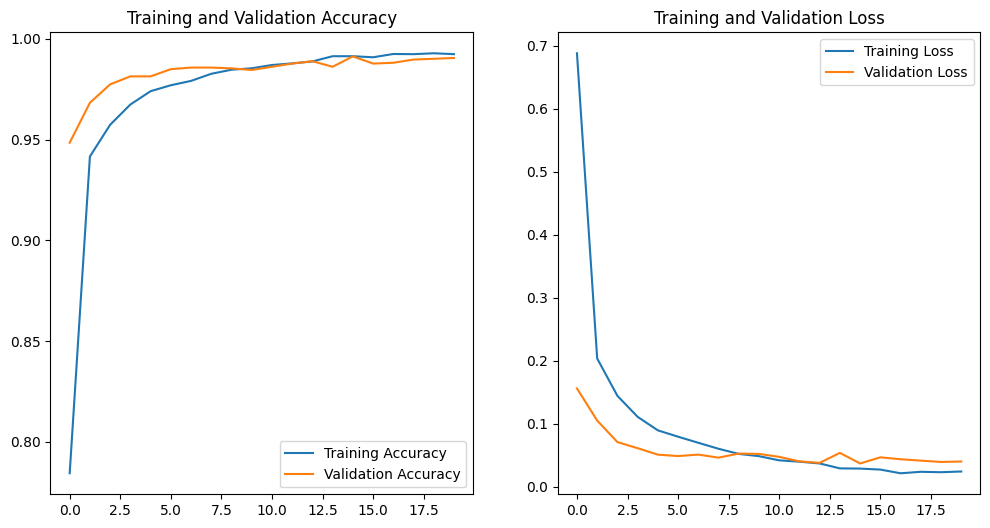

In [ ]:
import matplotlib.pyplot as plt

accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(epochs)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, accuracy, label='Training Accuracy')
plt.plot(epochs_range, val_accuracy, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

### Classification Report and Sample Predictions

Finally, let's generate a detailed classification report to see precision, recall, and f1-score for each class, and visualize some sample test images with their predicted and true labels.

In [ ]:
from sklearn.metrics import classification_report

# Get the predictions for the test data
predicted_classes = np.argmax(model.predict(x_test), axis=-1)

# Define class names for better readability in the report and plots
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(classification_report(y_test, predicted_classes, target_names=class_names))

263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
              precision    recall  f1-score   support

 T-shirt/top       0.99      1.00      1.00       862
     Trouser       0.99      0.99      0.99       921
    Pullover       0.98      1.00      0.99       813
       Dress       0.99      0.99      0.99       904
        Coat       0.98      0.99      0.99       804
      Sandal       0.99      0.98      0.99       773
       Shirt       0.99      0.99      0.99       814
     Sneaker       0.99      0.98      0.99       844
         Bag       0.99      0.98      0.99       828
  Ankle boot       0.99      0.98      0.98       837

    accuracy                           0.99      8400
   macro avg       0.99      0.99      0.99      8400
weighted avg       0.99      0.99      0.99      8400



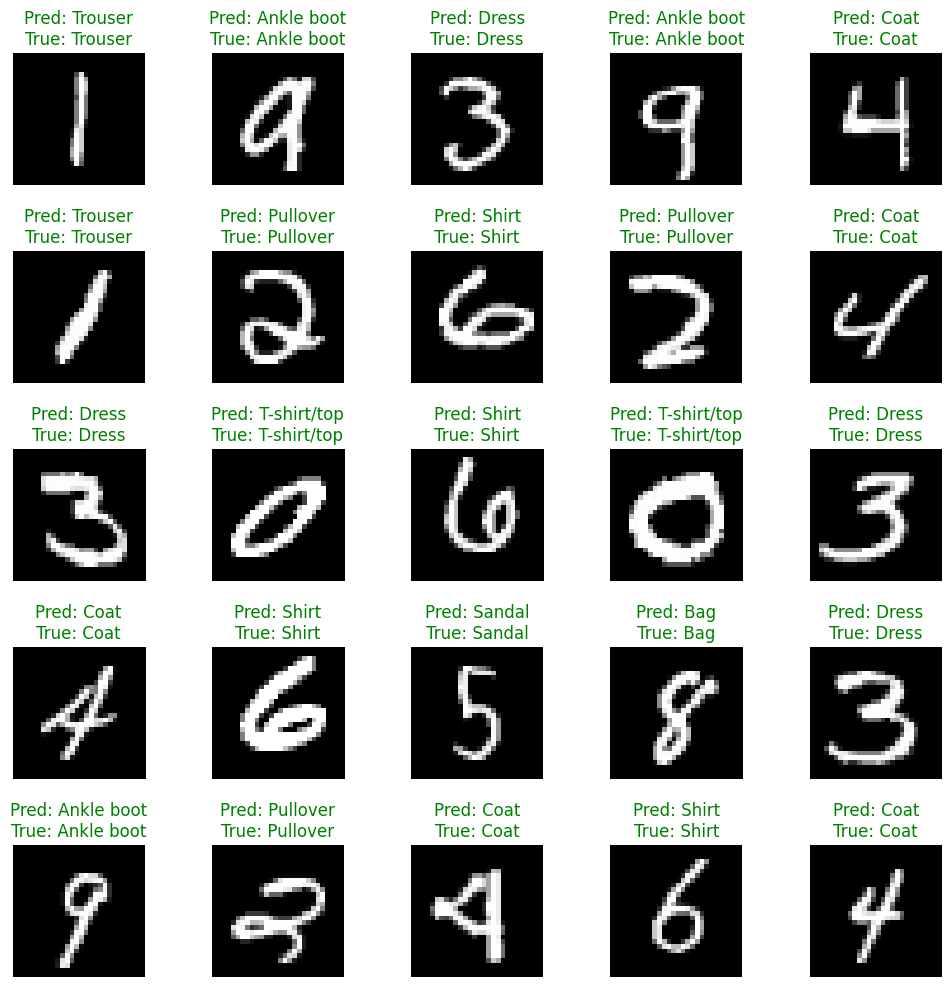

In [ ]:
L = 5
W = 5
fig, axes = plt.subplots(L, W, figsize = (12,12))
axes = axes.ravel()

for i in np.arange(0, L * W):
    axes[i].imshow(x_test[i].reshape(28,28), cmap='gray')
    axes[i].set_title(f"Pred: {class_names[predicted_classes[i]]}\nTrue: {class_names[int(y_test[i])]}",
                      color='green' if predicted_classes[i] == int(y_test[i]) else 'red')
    axes[i].axis('off')

plt.subplots_adjust(wspace=0.5, hspace=0.5)